In [1]:
%cd ..

c:\Users\s2558406\Documents\Repos\ram-experiments


c:\Users\s2558406\Documents\Repos\ram-experiments\venv\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [1]:
import numpy as np
import torch
import deepinv as dinv

In [4]:
data = np.load("work/data/h5/1meas_MID00619_FID129157_AI_RECON_SEQD_512_GF4_AX_RL_mod.npz")

In [5]:
y = torch.from_numpy(data["kraw"])
coil_maps = torch.from_numpy(data["csm"])

In [6]:
y.shape, y.dtype, y.abs().min(), y.abs().max(), coil_maps.shape, coil_maps.dtype,

(torch.Size([18, 512, 18, 512]),
 torch.complex64,
 tensor(0.),
 tensor(1328.6798),
 torch.Size([18, 18, 512, 512]),
 torch.complex64)

In [7]:
# ZWNH
y = y.permute(0, 2, 3, 1)
y = dinv.utils.MRIMixin.from_torch_complex(y) # B2NHW
y.shape

torch.Size([18, 2, 18, 512, 512])

In [8]:
# ZNYX
coil_maps = coil_maps.permute(0, 1, 3, 2) # BNXY

In [9]:
mask = (y!=0).float()[[0], [0], [0]].unsqueeze(0)

In [10]:
y = y[[9]]
coil_maps = coil_maps[[9]]

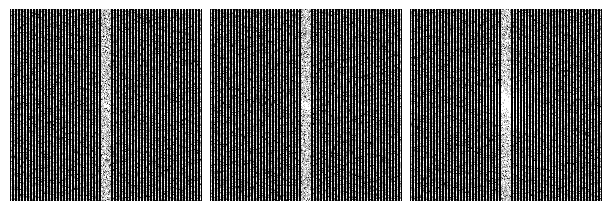

In [11]:
dinv.utils.plot([y[:, :, 5].clip(-1, 1), y[:, :, 10].clip(-1, 1), y[:, :, 15].clip(-1, 1)])

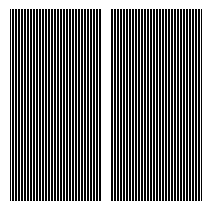

In [12]:
dinv.utils.plot(mask)

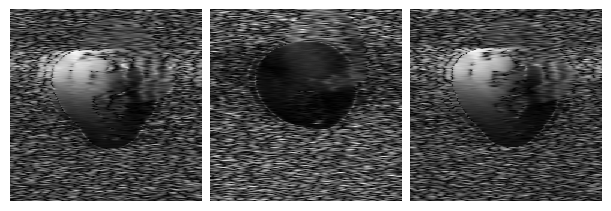

In [13]:
dinv.utils.plot([coil_maps[:, [5]], coil_maps[:, [10]], coil_maps[:, [15]],])

In [14]:
physics = dinv.physics.MultiCoilMRI(mask=mask, coil_maps=coil_maps)

In [25]:
coil_maps_espirit = physics.estimate_coil_maps(y, calib_size=26)

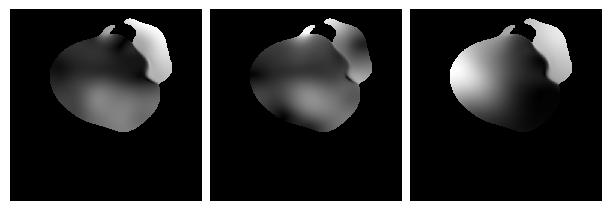

In [18]:
dinv.utils.plot([coil_maps_espirit[:, [5]], coil_maps_espirit[:, [10]], coil_maps_espirit[:, [15]],])

In [19]:
physics.update(coil_maps=coil_maps_espirit)

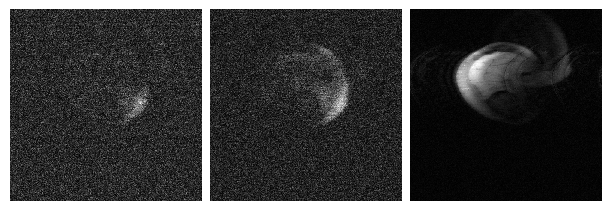

In [20]:
dinv.utils.plot([
    physics.kspace_to_im(y[:, :, 5]),
    physics.kspace_to_im(y[:, :, 10]),
    physics.kspace_to_im(y[:, :, 15])
])

In [21]:
x_zf = physics.A_adjoint(y)

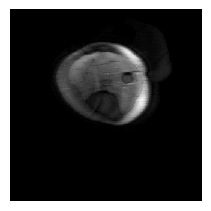

In [22]:
dinv.utils.plot(x_zf)

In [23]:
x_sense = physics.A_dagger(y)

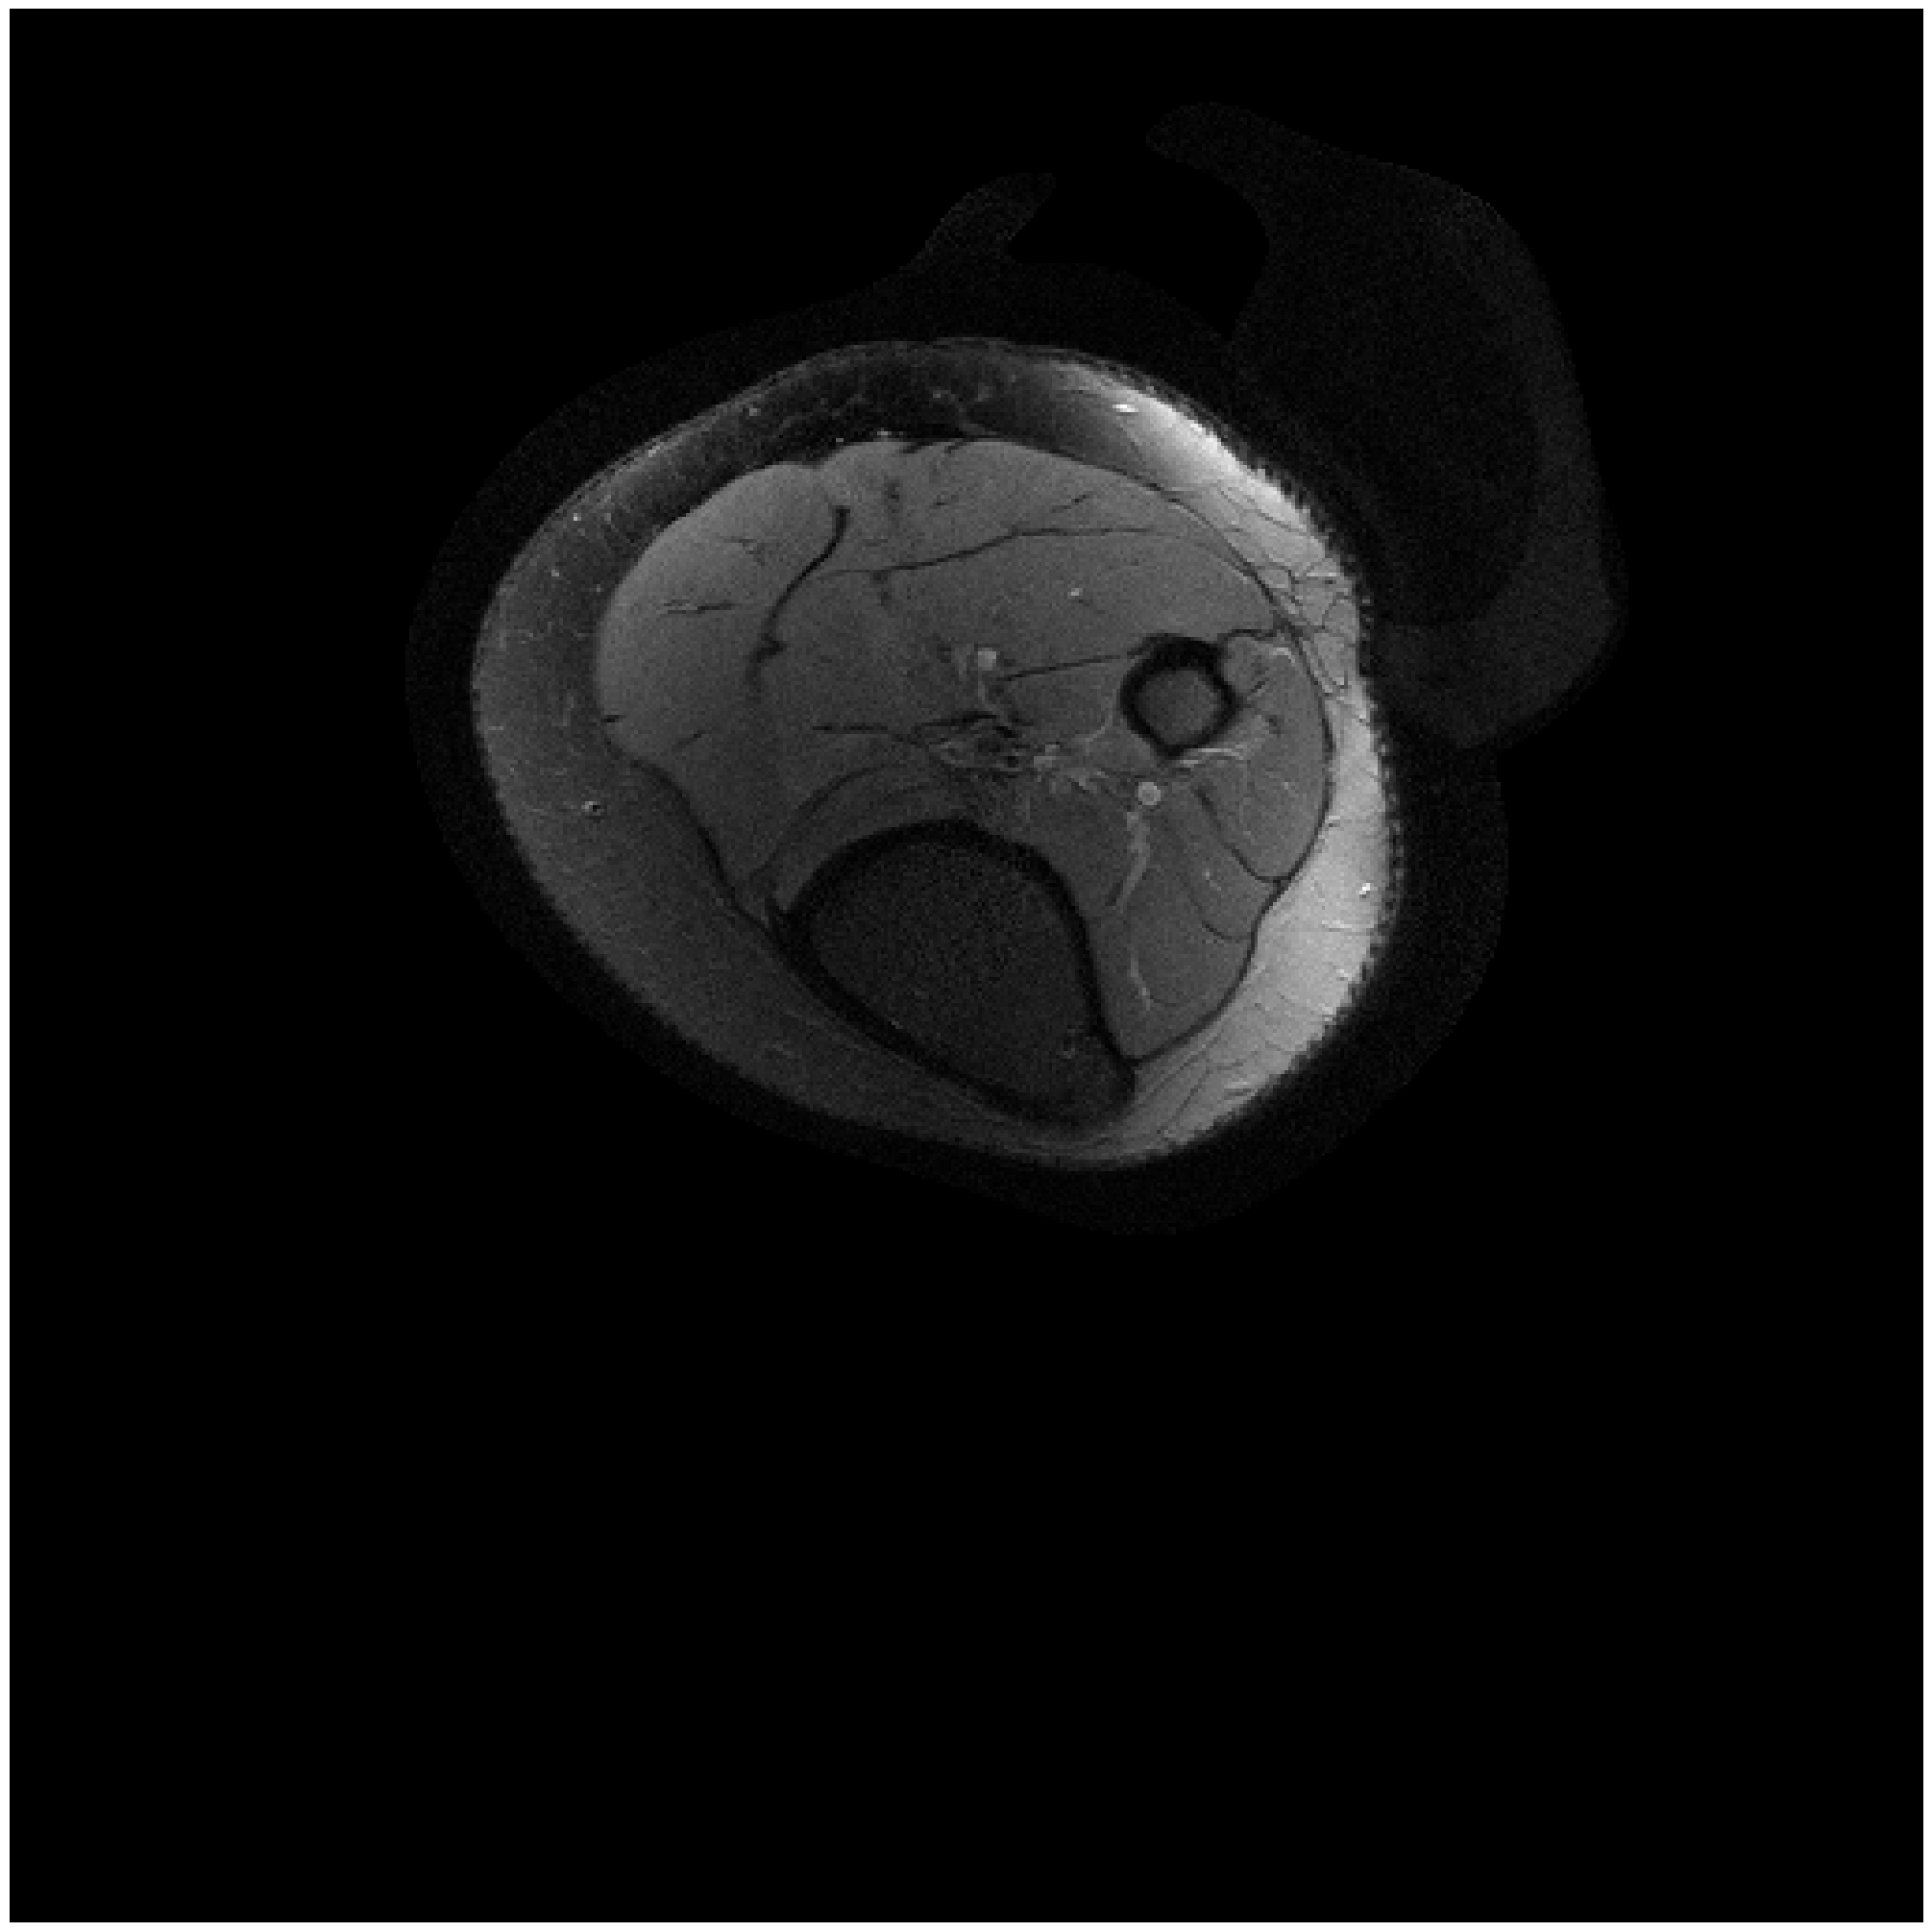

In [24]:
dinv.utils.plot(dinv.utils.complex_abs(x_sense).clip(-200, 200), figsize=(20,20))